# Predictive 4th Down Model — Playcaller Decision

**Goal:** Predict what decision a playcaller will actually make on 4th down (go-for-it, punt, field goal), then compare each playcaller's predicted decisions against the prescriptive EPA model's optimal recommendations.

**Pipeline:**
1. Load & filter data
2. Select pre-snap features; set target = actual coach decision
3. Train/test split (season-based)
4. Train XGBoost to predict actual decisions
5. Recompute prescriptive optimal labels
6. Per-playcaller agreement analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, log_loss, accuracy_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Filter Data

In [3]:
df = pd.read_csv('../encoded_fourth_downs.csv.gz', low_memory=False)
print(f'Raw rows: {len(df):,}')
print(f'Seasons: {sorted(df["season"].unique())}')

# Reconstruct actual coach decision
if 'play_type' in df.columns:
    play_type_map = {'run': 'go', 'pass': 'go', 'punt': 'punt', 'field_goal': 'field_goal'}
    df['decision'] = df['play_type'].map(play_type_map)
else:
    def get_decision(row):
        if row.get('play_type_pass', 0) == 1 or row.get('play_type_run', 0) == 1:
            return 'go'
        elif row.get('play_type_punt', 0) == 1:
            return 'punt'
        elif row.get('field_goal_attempt', 0) == 1:
            return 'field_goal'
        return np.nan
    df['decision'] = df.apply(get_decision, axis=1)

df_clean = df.dropna(subset=['decision']).copy()
df_clean = df_clean[df_clean['decision'].isin(['go', 'punt', 'field_goal'])]

print(f'\nUsable 4th down plays: {len(df_clean):,}')
print(df_clean['decision'].value_counts())

Raw rows: 38,762
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Usable 4th down plays: 34,897
decision
punt          19488
field_goal     8571
go             6838
Name: count, dtype: int64


## 2. Features & Target

Target is the **actual coach decision**. Same pre-snap feature set as the prescriptive model.

In [4]:
pre_snap_features = [
    'yardline_100', 'ydstogo', 'score_differential',
    'game_seconds_remaining', 'half_seconds_remaining', 'qtr',
    'posteam_timeouts_remaining', 'defteam_timeouts_remaining',
    'goal_to_go', 'shotgun', 'no_huddle', 'home_is_posteam',
]

pregame_epa_features = [
    'no_score_prob', 'opp_fg_prob', 'opp_td_prob', 'fg_prob', 'td_prob',
]

playcaller_cols = [c for c in df_clean.columns if c.startswith('playcaller_')]

df_clean['is_dynamic_era'] = (df_clean['season'] >= 2023).astype(int)

season_dummies = pd.get_dummies(df_clean['season'], prefix='season', drop_first=True)
df_clean = pd.concat([df_clean, season_dummies], axis=1)
season_feat_cols = list(season_dummies.columns)

all_features = (
    pre_snap_features + pregame_epa_features +
    playcaller_cols + ['is_dynamic_era'] + season_feat_cols
)
all_features = [f for f in all_features if f in df_clean.columns]

X = df_clean[all_features].copy()
y = df_clean['decision'].copy()   # <-- actual coach decision

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]

print(f'Features: {len(all_features)}')
print(f'Dataset:  {len(X):,} plays')
print(f'Target distribution:\n{y.value_counts()}')

Features: 113
Dataset:  34,897 plays
Target distribution:
decision
punt          19488
field_goal     8571
go             6838
Name: count, dtype: int64


## 3. Train/Test Split — Season-Based

2018-2023 train, 2024 test.

In [5]:
TEST_SEASON = 2024
season_col = df_clean.loc[mask, 'season']

train_idx = season_col[season_col < TEST_SEASON].index
test_idx  = season_col[season_col == TEST_SEASON].index

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train seasons: {sorted(season_col[train_idx].unique())}')
print(f'Test season:   {sorted(season_col[test_idx].unique())}')

Train: 26,351  |  Test: 4,556
Train seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Test season:   [np.int64(2024)]


## 4. Train XGBoost to Predict Actual Coach Decisions

In [7]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

param_dist = {
    'n_estimators':     randint(100, 600),
    'max_depth':        randint(3, 10),
    'learning_rate':    loguniform(0.01, 0.3),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 20),
    'gamma':            uniform(0, 5),
    'reg_alpha':        loguniform(0.001, 10),
    'reg_lambda':       loguniform(0.001, 10),
}

xgb_base = xgb.XGBClassifier(
    eval_metric='mlogloss', random_state=42, n_jobs=2, verbosity=0  # changed from -1
)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=15,                          # reduced from 30
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring={'accuracy': 'accuracy', 'neg_log_loss': 'neg_log_loss'},
    refit='neg_log_loss',
    n_jobs=1,                           # changed from -1 — no parallel CV workers
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train_enc)
predictive_model = search.best_estimator_

test_preds_enc = predictive_model.predict(X_test)
test_preds     = le.inverse_transform(test_preds_enc)
test_probs     = predictive_model.predict_proba(X_test)

print('\n=== Best Parameters ===')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

print('\n=== Test Set Performance (predicting actual coach decision) ===')
print(classification_report(y_test, test_preds, target_names=le.classes_))
print(f'Accuracy: {accuracy_score(y_test, test_preds):.4f}')
print(f'Log loss: {log_loss(y_test_enc, test_probs):.4f}')

Fitting 3 folds for each of 15 candidates, totalling 45 fits

=== Best Parameters ===
  colsample_bytree: 0.9332779646944658
  gamma: 0.8668232675388604
  learning_rate: 0.03781324384545034
  max_depth: 4
  min_child_weight: 8
  n_estimators: 487
  reg_alpha: 0.017654048052495083
  reg_lambda: 0.12030178871154672
  subsample: 0.8186841117373118

=== Test Set Performance (predicting actual coach decision) ===
              precision    recall  f1-score   support

  field_goal       1.00      1.00      1.00      1176
          go       0.98      0.93      0.96       960
        punt       0.97      0.99      0.98      2420

    accuracy                           0.98      4556
   macro avg       0.98      0.97      0.98      4556
weighted avg       0.98      0.98      0.98      4556

Accuracy: 0.9818
Log loss: 0.0591


## 5. Recompute Prescriptive Optimal Labels

Same bucketing logic as the prescriptive notebook. Requires `epa` column.

In [18]:
df_prescriptive = df_clean.dropna(subset=['epa']).copy()

df_prescriptive['ydstogo_bin'] = pd.cut(
    df_prescriptive['ydstogo'], bins=[0, 1, 3, 6, 10, 99],
    labels=['1', '2-3', '4-6', '7-10', '10+']
)
df_prescriptive['yardline_bin'] = pd.cut(
    df_prescriptive['yardline_100'], bins=[0, 20, 40, 60, 80, 100],
    labels=['opp_red_zone', 'opp_40', 'midfield', 'own_40', 'own_end']
)
df_prescriptive['score_diff_bin'] = pd.cut(
    df_prescriptive['score_differential'],
    bins=[-100, -14, -7, -3, 3, 7, 14, 100],
    labels=['down_14+', 'down_8-14', 'down_1-7', 'close', 'up_1-7', 'up_8-14', 'up_14+']
)
df_prescriptive['kickoff_era'] = df_prescriptive['season'].apply(
    lambda s: 'dynamic' if s >= 2023 else 'traditional'
)

group_cols = ['ydstogo_bin', 'yardline_bin', 'score_diff_bin', 'kickoff_era']

# ── CHANGED: compute EPA buckets on train seasons only to avoid leakage ──
train_prescriptive = df_prescriptive[df_prescriptive['season'] < TEST_SEASON]

epa_pivot = (
    train_prescriptive                                          # <-- was df_prescriptive
    .groupby(group_cols + ['decision'])['epa']
    .mean()
    .reset_index()
    .rename(columns={'epa': 'mean_epa'})
    .pivot_table(index=group_cols, columns='decision', values='mean_epa')
    .reset_index()
)
epa_pivot.columns.name = None

for col in ['go', 'punt', 'field_goal']:
    if col not in epa_pivot.columns:
        epa_pivot[col] = np.nan

epa_pivot['optimal_decision'] = epa_pivot[['go', 'punt', 'field_goal']].idxmax(axis=1)

df_prescriptive = df_prescriptive.merge(
    epa_pivot[group_cols + ['optimal_decision']], on=group_cols, how='left'
).dropna(subset=['optimal_decision'])

print(f'Rows with prescriptive label: {len(df_prescriptive):,}')
print(df_prescriptive['optimal_decision'].value_counts())

Rows with prescriptive label: 34,890
optimal_decision
punt          13091
go            12409
field_goal     9390
Name: count, dtype: int64


## 6. Per-Playcaller Agreement Analysis

In [25]:
# Score all plays that have complete features
X_full = df_prescriptive[all_features].copy()
X_full[X_full.select_dtypes(include='bool').columns] = \
    X_full.select_dtypes(include='bool').astype(int)

full_mask = X_full.notna().all(axis=1)
predicted_enc = predictive_model.predict(X_full[full_mask])
predicted     = le.inverse_transform(predicted_enc)

df_scored = df_prescriptive[full_mask].copy()
df_scored['predicted_decision'] = predicted

# ── CHANGED: flag which rows are test-season for clean evaluation ──
df_scored['is_test'] = (df_scored['season'] == TEST_SEASON).astype(int)

# Identify each row's playcaller from the one-hot columns
pc_cols_present = [c for c in playcaller_cols if c in df_scored.columns]
df_scored['playcaller'] = df_scored[pc_cols_present].apply(
    lambda row: next(
        (col.replace('playcaller_', '') for col in pc_cols_present if row[col] == 1),
        'Unknown'
    ),
    axis=1
)

# Agreement flags
df_scored['actual_matches_optimal']    = (df_scored['decision']           == df_scored['optimal_decision']).astype(int)
df_scored['predicted_matches_optimal'] = (df_scored['predicted_decision'] == df_scored['optimal_decision']).astype(int)

# ── CHANGED: report agreement rates on test season only ──
test_scored = df_scored[df_scored['is_test'] == 1]

overall_actual_agree    = test_scored['actual_matches_optimal'].mean()
overall_predicted_agree = test_scored['predicted_matches_optimal'].mean()
print(f'League-wide actual agreement with optimal (2024):    {overall_actual_agree:.1%}')
print(f'League-wide predicted agreement with optimal (2024): {overall_predicted_agree:.1%}')

League-wide actual agreement with optimal (2024):    68.2%
League-wide predicted agreement with optimal (2024): 68.1%


In [26]:
# Per-playcaller stats (min 20 plays)
MIN_PLAYS = 20

playcaller_stats = (
    test_scored
    .groupby('playcaller')
    .agg(
        n_plays              = ('decision', 'count'),
        actual_agree_rate    = ('actual_matches_optimal', 'mean'),
        predicted_agree_rate = ('predicted_matches_optimal', 'mean'),
    )
    .query(f'n_plays >= {MIN_PLAYS}')
    .sort_values('actual_agree_rate', ascending=False)
    .round(3)
)

print(f'Playcallers with >= {MIN_PLAYS} plays: {len(playcaller_stats)}')
print(playcaller_stats.to_string())

Playcallers with >= 20 plays: 36
                   n_plays  actual_agree_rate  predicted_agree_rate
playcaller                                                         
Bobby Slowik           149              0.752                 0.745
Klint Kubiak           131              0.748                 0.748
Kevin Stefanski        159              0.742                 0.717
Ken Dorsey             159              0.742                 0.717
Todd Monken            103              0.738                 0.699
Matt LaFleur           112              0.732                 0.732
Brian Daboll           140              0.714                 0.693
Sean Payton            133              0.714                 0.737
Ryan Grubb             121              0.711                 0.694
Shane Waldron          142              0.704                 0.690
Thomas Brown           142              0.704                 0.690
Shane Steichen         131              0.702                 0.702
Zac Taylor     

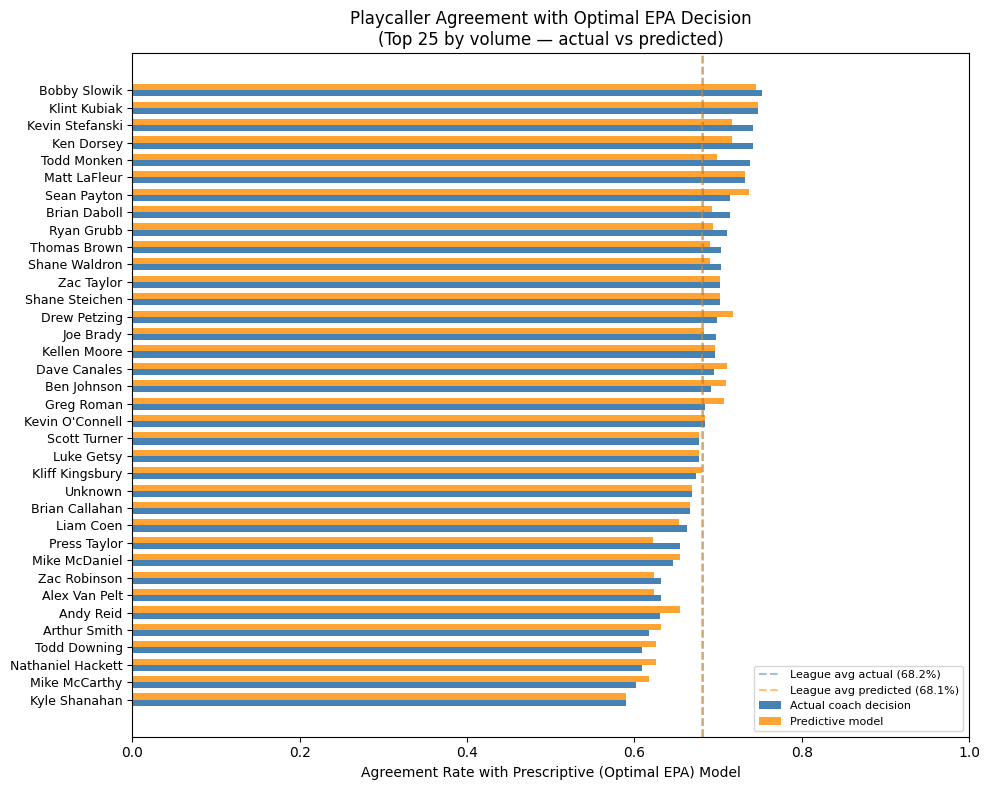

Saved: playcaller_agreement.png


In [32]:
# Bar chart: actual vs predicted agreement per playcaller (top 25 by volume)
plot_df = playcaller_stats.nlargest(40, 'n_plays').sort_values('actual_agree_rate')

fig, ax = plt.subplots(figsize=(10, 8))
y_pos      = np.arange(len(plot_df))
bar_height = 0.35

ax.barh(y_pos - bar_height/2, plot_df['actual_agree_rate'],    bar_height,
        label='Actual coach decision', color='steelblue')
ax.barh(y_pos + bar_height/2, plot_df['predicted_agree_rate'], bar_height,
        label='Predictive model', color='darkorange', alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index, fontsize=9)
ax.axvline(overall_actual_agree,    color='steelblue',  linestyle='--', alpha=0.5,
           label=f'League avg actual ({overall_actual_agree:.1%})')
ax.axvline(overall_predicted_agree, color='darkorange', linestyle='--', alpha=0.5,
           label=f'League avg predicted ({overall_predicted_agree:.1%})')
ax.set_xlabel('Agreement Rate with Prescriptive (Optimal EPA) Model')
ax.set_title('Playcaller Agreement with Optimal EPA Decision\n(Top 25 by volume — actual vs predicted)')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('playcaller_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: playcaller_agreement.png')

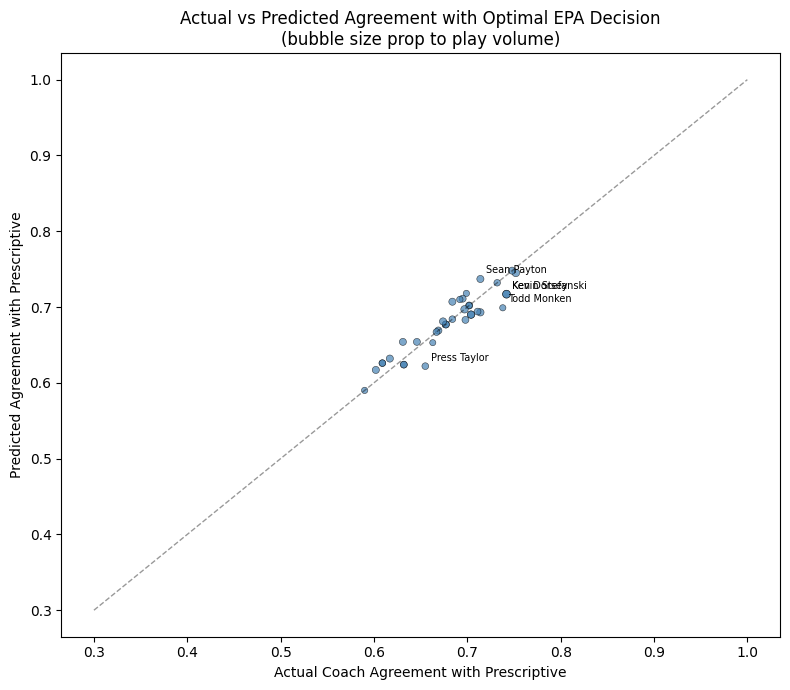

Saved: playcaller_agreement_scatter.png


In [28]:
# Scatter: actual vs predicted agreement — outliers = playcallers the model misjudges
playcaller_stats['diag_gap'] = (
    playcaller_stats['predicted_agree_rate'] - playcaller_stats['actual_agree_rate']
).abs()

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(
    playcaller_stats['actual_agree_rate'],
    playcaller_stats['predicted_agree_rate'],
    s=playcaller_stats['n_plays'] / 5,
    alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.4
)

lims = [0.3, 1.0]
ax.plot(lims, lims, 'k--', alpha=0.4, linewidth=1)

for pc in playcaller_stats.nlargest(5, 'diag_gap').index:
    row = playcaller_stats.loc[pc]
    ax.annotate(pc, (row['actual_agree_rate'], row['predicted_agree_rate']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Actual Coach Agreement with Prescriptive')
ax.set_ylabel('Predicted Agreement with Prescriptive')
ax.set_title('Actual vs Predicted Agreement with Optimal EPA Decision\n(bubble size prop to play volume)')
plt.tight_layout()
plt.savefig('playcaller_agreement_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: playcaller_agreement_scatter.png')

In [29]:
print('=== Most Optimal Playcallers ===')
print(playcaller_stats['actual_agree_rate'].nlargest(5).to_string())

print('\n=== Least Optimal Playcallers ===')
print(playcaller_stats['actual_agree_rate'].nsmallest(5).to_string())

=== Most Optimal Playcallers ===
playcaller
Bobby Slowik       0.752
Klint Kubiak       0.748
Kevin Stefanski    0.742
Ken Dorsey         0.742
Todd Monken        0.738

=== Least Optimal Playcallers ===
playcaller
Kyle Shanahan        0.590
Mike McCarthy        0.602
Todd Downing         0.609
Nathaniel Hackett    0.609
Arthur Smith         0.617


In [30]:
# ─── Find all plays where the model predicts a PUNT inside the opponent's 40 ───

# yardline_100 = yards from the opponent's end zone
# Inside opponent's 40 means yardline_100 <= 40 (i.e. 1–40 yards away from scoring)

predicted_punts_opp40 = test_scored[
    (test_scored['predicted_decision'] == 'punt') &
    (test_scored['yardline_100'] <= 40)
].copy()

print(f"Total predicted punts inside opponent's 40: {len(predicted_punts_opp40):,}\n")

# ─── Per-playcaller breakdown ───────────────────────────────────────────────────

punt_by_playcaller = (
    predicted_punts_opp40
    .groupby('playcaller')
    .agg(
        predicted_punts_opp40 = ('predicted_decision', 'count'),
        avg_yardline_100       = ('yardline_100', 'mean'),   # avg distance from end zone
        avg_ydstogo            = ('ydstogo', 'mean'),
    )
    .sort_values('predicted_punts_opp40', ascending=False)
    .round(2)
)

# Attach total 4th-down play count for context (punt rate)
total_plays = (
    df_scored
    .groupby('playcaller')
    .size()
    .rename('total_4th_downs')
)

punt_by_playcaller = punt_by_playcaller.join(total_plays)
punt_by_playcaller['punt_rate_opp40'] = (
    punt_by_playcaller['predicted_punts_opp40'] / punt_by_playcaller['total_4th_downs']
).round(3)

print("=== Predicted Punts Inside Opponent's 40 — by Playcaller ===")
print(punt_by_playcaller.to_string())

# ─── Play-level detail (optional — see each specific situation) ─────────────────

cols_to_show = [
    'playcaller', 'season', 'yardline_100', 'ydstogo',
    'score_differential', 'game_seconds_remaining',
    'predicted_decision', 'decision', 'optimal_decision'
]
cols_present = [c for c in cols_to_show if c in predicted_punts_opp40.columns]

print(f"\n=== Play-level sample (first 20) ===")
print(predicted_punts_opp40[cols_present].head(20).to_string(index=False))

Total predicted punts inside opponent's 40: 43

=== Predicted Punts Inside Opponent's 40 — by Playcaller ===
                   predicted_punts_opp40  avg_yardline_100  avg_ydstogo  total_4th_downs  punt_rate_opp40
playcaller                                                                                               
Ken Dorsey                             4             39.00        10.75              369            0.011
Kevin Stefanski                        4             39.00        10.75              850            0.005
Andy Reid                              3             39.00        12.00              709            0.004
Zac Robinson                           3             39.00        13.67              245            0.012
Unknown                                3             36.67        10.67             1714            0.002
Kellen Moore                           2             39.50        12.50              893            0.002
Brian Daboll                           2   

In [31]:
# ─── Prediction accuracy for punts inside opponent's 40 ────────────────────────

# Was the predicted punt what the coach actually did?
predicted_punts_opp40['prediction_correct'] = (
    predicted_punts_opp40['predicted_decision'] == predicted_punts_opp40['decision']
).astype(int)

overall_accuracy = predicted_punts_opp40['prediction_correct'].mean()
print(f"Overall prediction accuracy (punt inside opp 40): {overall_accuracy:.1%}")
print(f"Correct: {predicted_punts_opp40['prediction_correct'].sum():,} / {len(predicted_punts_opp40):,}\n")

# ─── Per-playcaller accuracy ────────────────────────────────────────────────────

accuracy_by_playcaller = (
    predicted_punts_opp40
    .groupby('playcaller')
    .agg(
        n_predicted_punts  = ('predicted_decision', 'count'),
        n_correct          = ('prediction_correct', 'sum'),
        accuracy           = ('prediction_correct', 'mean'),
    )
    .sort_values('accuracy', ascending=False)
    .round(3)
)

print("=== Per-Playcaller Accuracy — Predicted Punts Inside Opp 40 ===")
print(accuracy_by_playcaller.to_string())

# ─── What did the coach actually do on incorrect predictions? ───────────────────

incorrect = predicted_punts_opp40[predicted_punts_opp40['prediction_correct'] == 0]

print(f"\n=== When the model was wrong, coach actually chose: ===")
print(incorrect['decision'].value_counts())
print(incorrect['decision'].value_counts(normalize=True).round(3).mul(100).astype(str) + '%')

Overall prediction accuracy (punt inside opp 40): 95.3%
Correct: 41 / 43

=== Per-Playcaller Accuracy — Predicted Punts Inside Opp 40 ===
                   n_predicted_punts  n_correct  accuracy
playcaller                                               
Andy Reid                          3          3       1.0
Bobby Slowik                       1          1       1.0
Brian Daboll                       2          2       1.0
Greg Roman                         1          1       1.0
Joe Brady                          2          2       1.0
Kellen Moore                       2          2       1.0
Ken Dorsey                         4          4       1.0
Kevin Stefanski                    4          4       1.0
Kliff Kingsbury                    1          1       1.0
Klint Kubiak                       1          1       1.0
Kyle Shanahan                      2          2       1.0
Ryan Grubb                         1          1       1.0
Nathaniel Hackett                  1          1   

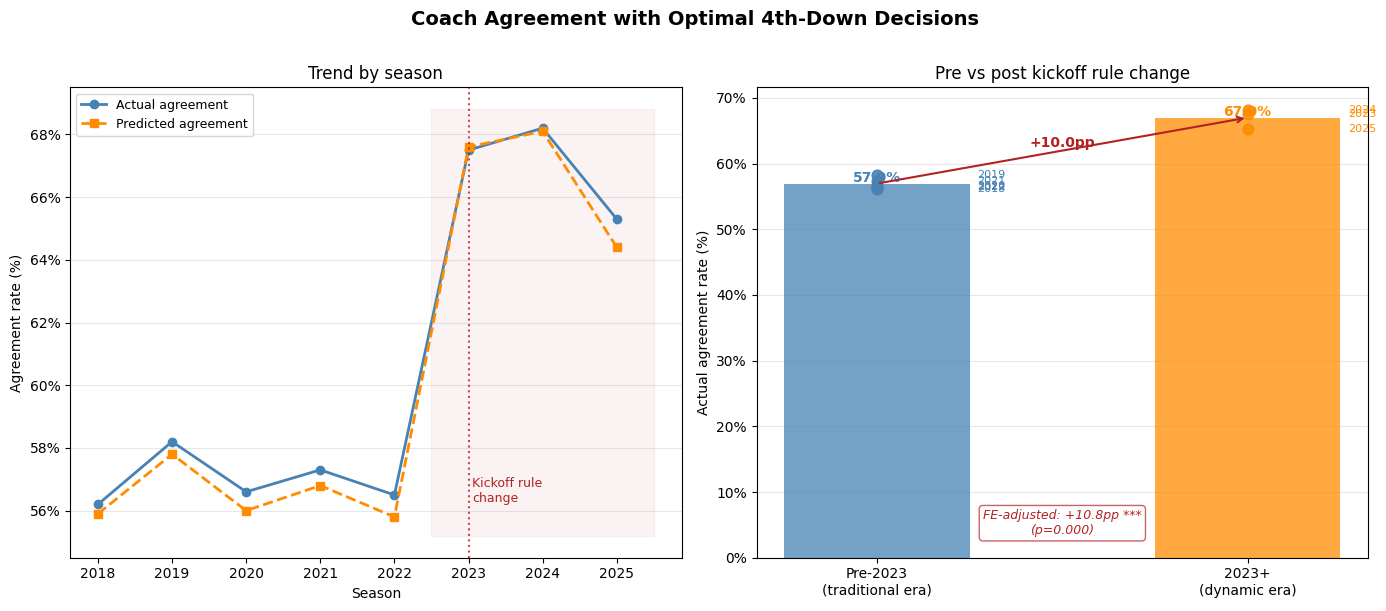

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Coach Agreement with Optimal 4th-Down Decisions", fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: Agreement trend by season ──────────────────────────────────────────

ax1 = axes[0]

seasons        = yearly_agreement.index.tolist()
actual_rates   = yearly_agreement['actual_agree_rate'].tolist()
predicted_rates = yearly_agreement['predicted_agree_rate'].tolist()

ax1.plot(seasons, [r * 100 for r in actual_rates],
         marker='o', linewidth=2, color='steelblue', label='Actual agreement')
ax1.plot(seasons, [r * 100 for r in predicted_rates],
         marker='s', linewidth=2, linestyle='--', color='darkorange', label='Predicted agreement')

ax1.axvline(x=2023, color='firebrick', linestyle=':', linewidth=1.5, alpha=0.8)
ax1.text(2023.05, ax1.get_ylim()[0] + 1, 'Kickoff rule\nchange',
         color='firebrick', fontsize=9, va='bottom')

ax1.fill_betweenx([ax1.get_ylim()[0], ax1.get_ylim()[1]],
                  2022.5, max(seasons) + 0.5, alpha=0.05, color='firebrick')

ax1.set_xlabel('Season')
ax1.set_ylabel('Agreement rate (%)')
ax1.set_title('Trend by season')
ax1.set_xticks(seasons)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Pre vs post kickoff rule — means with individual season dots ────────

ax2 = axes[1]

pre_seasons  = [s for s in seasons if s < 2023]
post_seasons = [s for s in seasons if s >= 2023]
pre_rates    = [r * 100 for r, s in zip(actual_rates, seasons) if s < 2023]
post_rates   = [r * 100 for r, s in zip(actual_rates, seasons) if s >= 2023]

pre_mean  = np.mean(pre_rates)
post_mean = np.mean(post_rates)

bar_colors = ['steelblue', 'darkorange']
bars = ax2.bar(['Pre-2023\n(traditional era)', '2023+\n(dynamic era)'],
               [pre_mean, post_mean],
               color=bar_colors, alpha=0.75, width=0.5, zorder=2)

for season, rate in zip(pre_seasons, pre_rates):
    ax2.scatter(0, rate, color='steelblue', s=60, zorder=3, alpha=0.9)
    ax2.text(0.27, rate, str(season), va='center', fontsize=8, color='steelblue')

for season, rate in zip(post_seasons, post_rates):
    ax2.scatter(1, rate, color='darkorange', s=60, zorder=3, alpha=0.9)
    ax2.text(1.27, rate, str(season), va='center', fontsize=8, color='darkorange')

ax2.text(0, pre_mean + 0.3, f'{pre_mean:.1f}%', ha='center', fontsize=10, fontweight='bold', color='steelblue')
ax2.text(1, post_mean + 0.3, f'{post_mean:.1f}%', ha='center', fontsize=10, fontweight='bold', color='darkorange')

diff = post_mean - pre_mean
ax2.annotate('', xy=(1, post_mean), xytext=(0, pre_mean),
             arrowprops=dict(arrowstyle='->', color='firebrick', lw=1.5))
ax2.text(0.5, (pre_mean + post_mean) / 2 + 0.5,
         f'{diff:+.1f}pp', ha='center', fontsize=10, color='firebrick', fontweight='bold')

# FE model results annotation
fe_coef = model_fe.params['post_kickoff_rule'] * 100
fe_p    = model_fe.pvalues['post_kickoff_rule']
sig     = '***' if fe_p < 0.001 else '**' if fe_p < 0.01 else '*' if fe_p < 0.05 else 'n.s.'
ax2.text(0.5, 0.05,
         f'FE-adjusted: {fe_coef:+.1f}pp {sig}\n(p={fe_p:.3f})',
         transform=ax2.transAxes, ha='center', fontsize=9,
         color='firebrick', style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='firebrick', alpha=0.7))

ax2.set_ylabel('Actual agreement rate (%)')
ax2.set_title('Pre vs post kickoff rule change')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.grid(axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig('coach_agreement_kickoff_era.png', dpi=150, bbox_inches='tight')
plt.show()